# Cluatring based ob price - UTM

In [1]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors

In [2]:
train_df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")

In [8]:
df_cluster = train_df.copy()

x_train = train_df[['log_target_price', 'utm_x', 'utm_y']].copy()

kmeans = KMeans(n_clusters=10, random_state=42)
df_cluster['cluster'] = kmeans.fit_predict(x_train)

centers = kmeans.cluster_centers_

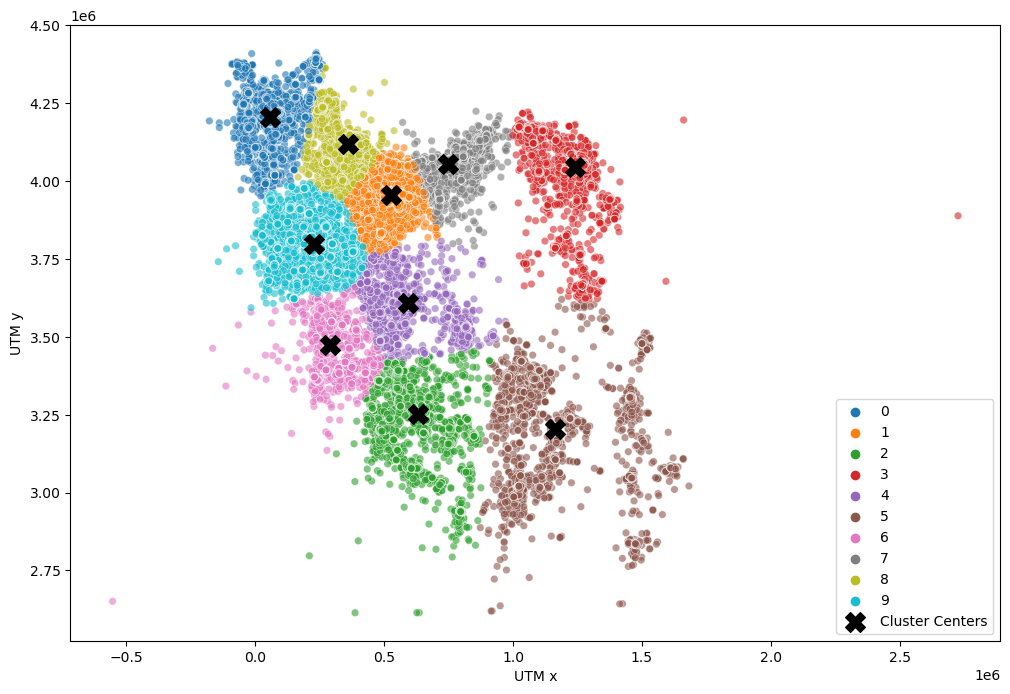

In [43]:
plt.figure(figsize=(12, 8))
sns.scatterplot(
    x='utm_x', y='utm_y',
    hue='cluster',
    palette='tab10',
    data=df_cluster,
    legend='full',
    alpha=0.6,
    s=30)


plt.scatter(
    centers[:, 1],  # utm_x
    centers[:, 2],  # utm_y
    c='black',
    s=200,
    marker='X',
    label='Cluster Centers')


plt.xlabel('UTM x')
plt.ylabel('UTM y')
plt.legend()
plt.show()

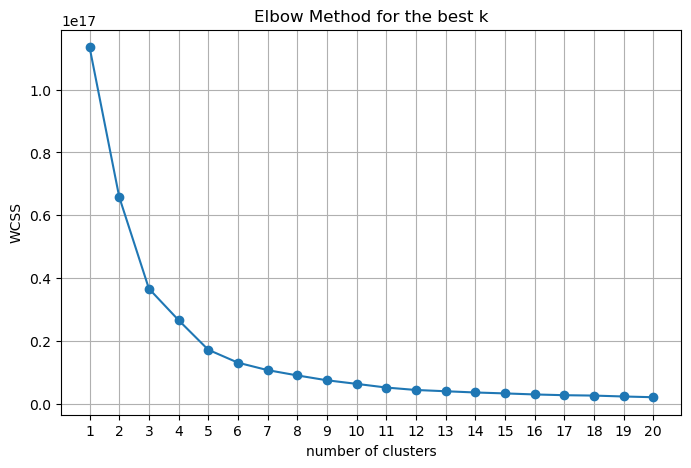

In [52]:
wcss = []
K_range = range(1, 21)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(x_train)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(K_range, wcss, marker='o')
plt.title('Elbow Method for the best k')
plt.xlabel('number of clusters')
plt.ylabel('WCSS')
plt.xticks(K_range)
plt.grid(True)
plt.show()

In [3]:
dbscan_data = train_df.copy()
x_train = dbscan_data[['utm_x', 'utm_y', 'log_target_price']]

In [5]:
# DBSCAN
dbscan = DBSCAN(eps=0.8, min_samples=50, n_jobs=-1)
clusters = dbscan.fit_predict(x_train)
dbscan_data['cluster'] = clusters

# Cluster centers
centers = dbscan_data.groupby('cluster')[['utm_x', 'utm_y', 'log_target_price']].mean()

In [6]:
dbscan_data["cluster"].value_counts()

cluster
-1      524586
 5       32056
 11      23322
 25      12592
 55       9476
         ...  
 304        50
 305        50
 300        50
 306        50
 307        50
Name: count, Length: 309, dtype: int64

/home/lifeweb/.local/lib/python3.8/site-packages/IPython/core/pylabtools.py:152: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


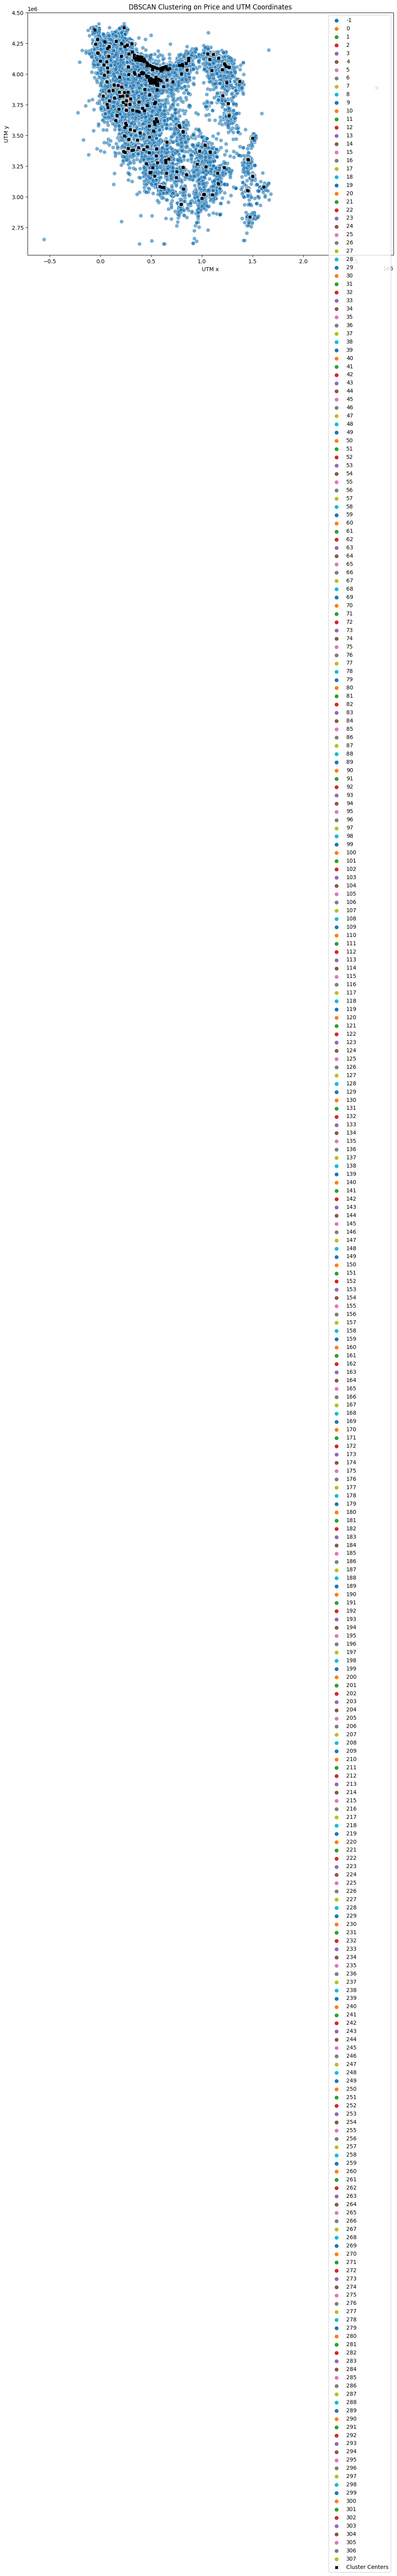

In [7]:
plt.figure(figsize=(12, 8))
sns.scatterplot(data=dbscan_data, x='utm_x', y='utm_y', hue='cluster', palette='tab10', s=50, alpha=0.6)
plt.scatter(centers['utm_x'], centers['utm_y'], c='black', s=25, marker='X', label='Cluster Centers')
plt.title('DBSCAN Clustering on Price and UTM Coordinates')
plt.xlabel('UTM x')
plt.ylabel('UTM y')
plt.legend()
plt.show()